In [16]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import seaborn as sns
import cobra

model = cobra.io.load_json_model('e_coli_core-1.json')

data = pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")
activities = dict(zip(data["# Reaction ID"], 
                      data[" reaction activity [mmol/gDW/h] "]))

### Task 1

a) In the flux simulation, the flux in a linear pathway are equal because the model was at a steady state. This means whatever is produced by a reaction has to be used by the next one. Although, the maximal activity are different. They are estimated from the expression level of each enzyme so that they don't have to be equal. Since the enzymes are expressed at different levels, their maximal activity also vary. For example in glycolysis, PGI has a maximal activity of 11.1, while TPI has 70 mmol/gDW/hour. When the pathway is actually used in the model, the enzyme with lowest maximal activity can limit how much flux can pass through the whole pipeline, creating a bottleneck.

b) It's either 0 or no data.
- 0 would mean that the reaction is within the expression data, but its maximal activity is zero. This would mean that no enzyme expression was detected so the reaction is not able to carry flux under these conditions.
- No data would mean that there is no expression data available for this reaction. Unlike a 0 value this doesn't mean that reaction has no actiivity. It simply means that the expression data cannot be used to constraint it, so the reaction keeps its default bounds in the model.

### Task 2

What is the lower and upper bound of EX_glc__D_e and is it in the max activities csv file?


In [17]:
reaction = model.reactions.get_by_id("EX_glc__D_e")

print(reaction.lower_bound)
print(reaction.upper_bound)
print("EX_glc__D_e" in activities)

-10.0
1000.0
False


Observations: 
As EX_glc__D_e is not in the csv file with the max activities, following function is sufficient to meet all requirements. It still has the pre existing lower bound of -10, so we set it to -1000 afterwards.


In [18]:
# Changing values to -value and value
for reaction in model.reactions:
    if reaction.id in activities:

        value = activities[reaction.id]

        if reaction.reversibility:
            reaction.lower_bound = -value
            reaction.upper_bound = value
        else:
            reaction.upper_bound = value

model.reactions.get_by_id("EX_glc__D_e").lower_bound = -1000


In [19]:
# Making sure that lower bound has not changed
reaction = model.reactions.get_by_id("ATPM")

print(reaction.lower_bound)
print(reaction.upper_bound)

8.39
1000.0


In [20]:
#print all bounds

print(len(model.reactions))
for reaction in model.reactions:
    print(reaction.id, "| lower bound: ", reaction.lower_bound, "AND upper bound: ", reaction.upper_bound)

95
PFK | lower bound:  0.0 AND upper bound:  13.1
PFL | lower bound:  0.0 AND upper bound:  0.0
PGI | lower bound:  -11.1 AND upper bound:  11.1
PGK | lower bound:  -24.0 AND upper bound:  24.0
PGL | lower bound:  0.0 AND upper bound:  7.3
ACALD | lower bound:  -0.0 AND upper bound:  0.0
AKGt2r | lower bound:  -0.0 AND upper bound:  0.0
PGM | lower bound:  -21.7 AND upper bound:  21.7
PIt2r | lower bound:  -5.2 AND upper bound:  5.2
ALCD2x | lower bound:  -0.0 AND upper bound:  0.0
ACALDt | lower bound:  -1000.0 AND upper bound:  1000.0
ACKr | lower bound:  -2.5 AND upper bound:  2.5
PPC | lower bound:  0.0 AND upper bound:  3.6
ACONTa | lower bound:  -21.4 AND upper bound:  21.4
ACONTb | lower bound:  -21.4 AND upper bound:  21.4
ATPM | lower bound:  8.39 AND upper bound:  1000.0
PPCK | lower bound:  0.0 AND upper bound:  13.3
ACt2r | lower bound:  -3.6 AND upper bound:  3.6
PPS | lower bound:  0.0 AND upper bound:  3.1
ADK1 | lower bound:  -27.4 AND upper bound:  27.4
AKGDH | lower b

### Task 3

In [21]:
solution = model.optimize()

print("Max biomass production rate:", solution.objective_value)
print("Glucose uptake:", solution.fluxes["EX_glc__D_e"])

Max biomass production rate: 0.8732862458582367
Glucose uptake: -10.620456510742805


The maximal biomass production rate is about 0.8732. Glucose uptake ends up at about 10.62 mmol/gDW/hour even though up to 1000 is allowed. so growth is limited by the enzyme activity and not glucose.

In [22]:
glucose = model.reactions.get_by_id("EX_glc__D_e")

glucose.lower_bound = -5
print(glucose.lower_bound, glucose.upper_bound)

-5 1000.0


The glucose exchange reaction bound describes how much glucose is available and can be uptaken by the cell. It is an external nutrient limitation. The expression based bounds describe how much flux can each enzyme carry given how much of it is expressed.

In [23]:
solution = model.optimize()

print("Max biomass production rate:", solution.objective_value)

Max biomass production rate: 0.41559777509290663


With the glucose bound of 5 mmol/gDW/hour the maximal biomass production rate drops from about 0.8732 to 0.4156. Glucose availability is now the bottleneck and the enzyme capacities are no longer reached, so less carbon and energy are available for biomass and growth rate goes down.

### Task 4

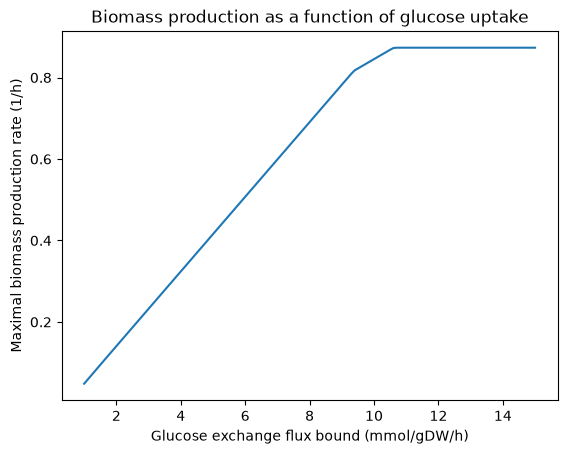

0.8732862458582383


In [30]:
glucose_bounds = np.arange(1, 15.1, 0.1)
growth_rates = []

glucose = model.reactions.get_by_id("EX_glc__D_e")

for bound in glucose_bounds:
    glucose.lower_bound = -bound
    solution = model.optimize()
    growth_rates.append(solution.objective_value)

plt.plot(glucose_bounds, growth_rates)
plt.xlabel("Glucose exchange flux bound (mmol/gDW/h)")
plt.ylabel("Maximal biomass production rate (1/h)")
plt.title("Biomass production as a function of glucose uptake")

plt.show()
plateau_value = max(growth_rates)
print(plateau_value)

The growth rate does not increase indefinitely with increasing glucose exchange flux bound. The maximal biomass production rate first increases almost linearly as the glucose uptake bound increases, meaning that the glucose availability is limiting growth in this range. However, at about 10.5–11 mmol/gDW/h, the curve reaches a plateau of 0.87 $h^{-1}$ approx. Beyond this point, allowing more glucose uptake does not increase the predicted growth rate, indicating that glucose is no longer the limiting factor and that another constraint in the enzyme activity-constrained metabolic model becomes limiting.

In [25]:
for bound in [5, 10, 14]:
    glucose.lower_bound = -bound
    solution = model.optimize()
    print("Glucose bound:", bound)
    for reaction in model.exchanges:
        if abs(solution.fluxes[reaction.id]) > 1e-6:
            print("  ", reaction.id, round(solution.fluxes[reaction.id], 3))

Glucose bound: 5
   EX_co2_e 12.314
   EX_glc__D_e -5.0
   EX_h_e 8.337
   EX_h2o_e 15.341
   EX_nh4_e -2.266
   EX_o2_e -11.834
   EX_pi_e -1.529
Glucose bound: 10
   EX_ac_e 1.252
   EX_co2_e 21.527
   EX_glc__D_e -10.0
   EX_h_e 18.207
   EX_h2o_e 27.684
   EX_nh4_e -4.609
   EX_o2_e -20.55
   EX_pi_e -3.109
Glucose bound: 14
   EX_ac_e 2.5
   EX_co2_e 21.56
   EX_glc__D_e -10.62
   EX_h_e 20.018
   EX_h2o_e 27.921
   EX_nh4_e -4.762
   EX_o2_e -20.55
   EX_pi_e -3.213


In the second part EX_ac_e is activated, and at a bound of 5 no acetate is secreted while at a bound of 10 about 1.25 mmol/gDW/hour is secreted. At the plateau it stays at 2.5. Since oxygen update is limited, the extra glucose cannot be fully utilized and part of the carbon is then secreted as acetate. 